<a href="https://www.kaggle.com/code/omborse771924/student-performance-study-habits-dataset-eda?scriptVersionId=336285428" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv')

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.tail()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


In [5]:
df.info

<bound method DataFrame.info of      student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0             1    Male               4.0                98.0          6.5   
1             2  Female               6.3               100.0          5.7   
2             3    Male               4.9                85.3          7.9   
3             4    Male               2.6                77.5          8.0   
4             5    Male               2.2                89.6          4.6   
..          ...     ...               ...                 ...          ...   
995         996    Male               2.8                75.4          8.2   
996         997    Male               6.7                88.4          7.1   
997         998  Female               2.6                84.5          8.0   
998         999  Female               4.6                85.3          8.1   
999        1000    Male               3.9                77.4          6.1   

    parental_education internet

In [6]:
df.describe

<bound method NDFrame.describe of      student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0             1    Male               4.0                98.0          6.5   
1             2  Female               6.3               100.0          5.7   
2             3    Male               4.9                85.3          7.9   
3             4    Male               2.6                77.5          8.0   
4             5    Male               2.2                89.6          4.6   
..          ...     ...               ...                 ...          ...   
995         996    Male               2.8                75.4          8.2   
996         997    Male               6.7                88.4          7.1   
997         998  Female               2.6                84.5          8.0   
998         999  Female               4.6                85.3          8.1   
999        1000    Male               3.9                77.4          6.1   

    parental_education intern

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [8]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [9]:
df.drop(columns=['parental_education'], inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'internet_access', 'extracurricular_activities',
       'part_time_job', 'previous_grade', 'final_exam_score', 'final_grade'],
      dtype='object')

## EDA

First Five Rows
   student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0           1    Male               4.0                98.0          6.5   
1           2  Female               6.3               100.0          5.7   
2           3    Male               4.9                85.3          7.9   
3           4    Male               2.6                77.5          8.0   
4           5    Male               2.2                89.6          4.6   

  internet_access extracurricular_activities part_time_job  previous_grade  \
0             Yes                        Yes            No            76.9   
1             Yes                        Yes           Yes            75.5   
2             Yes                         No           Yes            88.5   
3             Yes                        Yes            No            85.1   
4             Yes                         No           Yes            61.8   

   final_exam_score final_grade  
0             100.0     

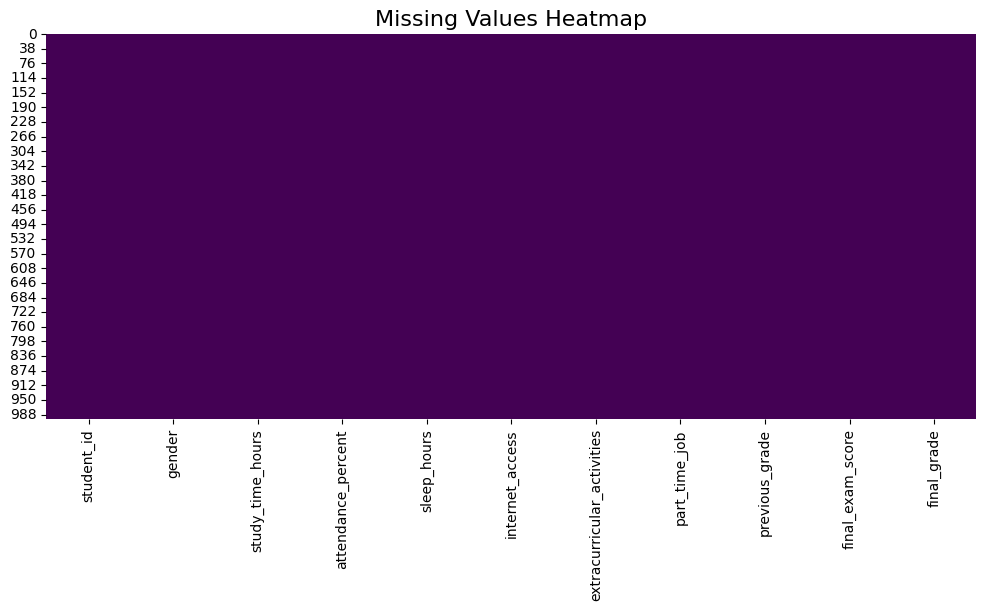

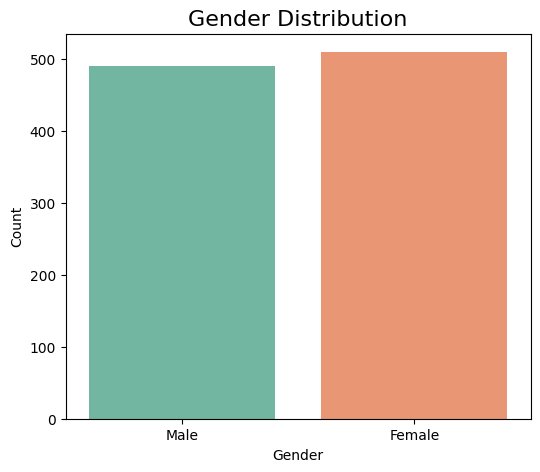

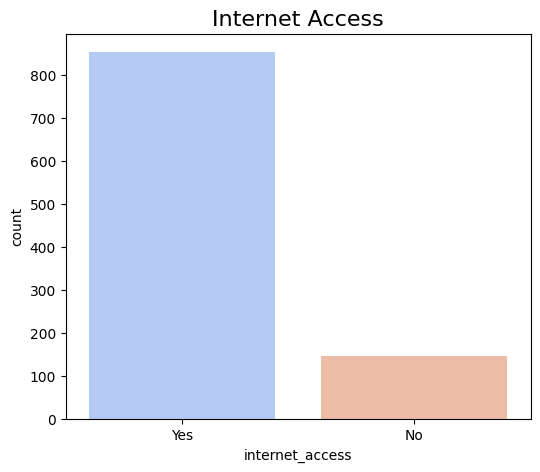

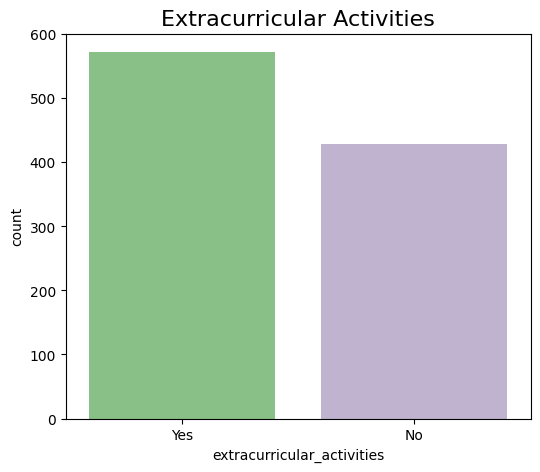

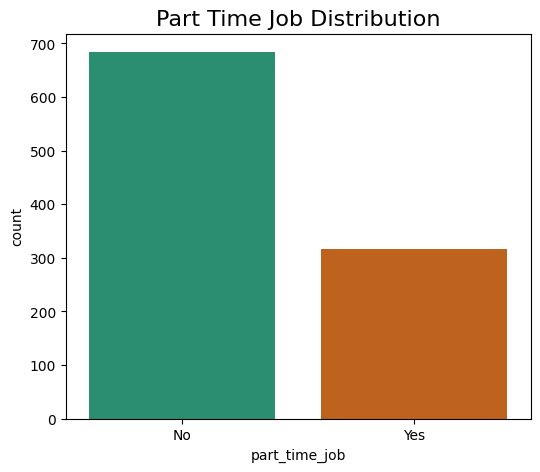

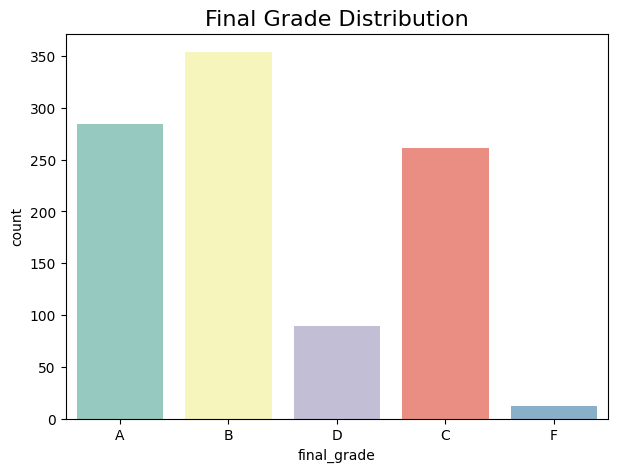

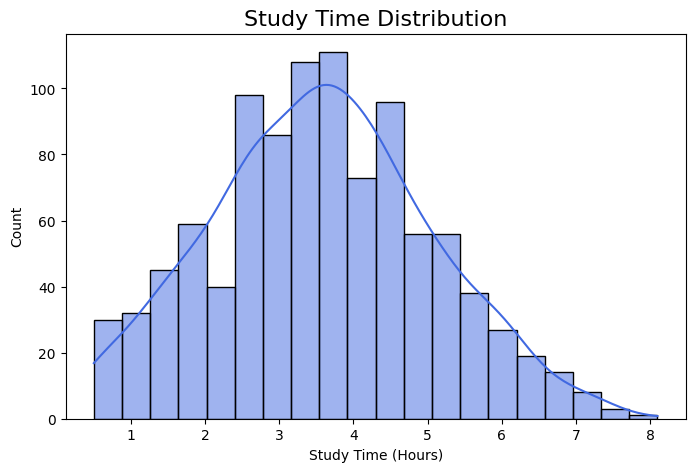

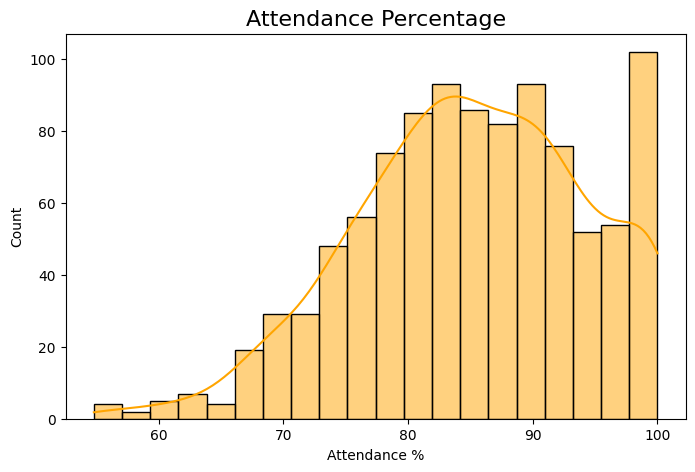

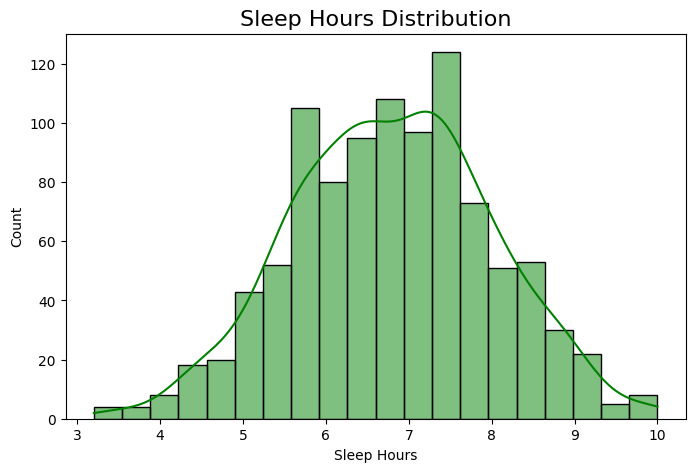

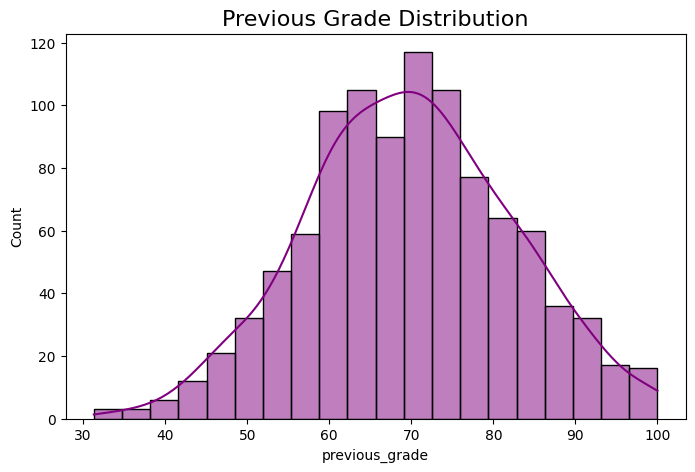

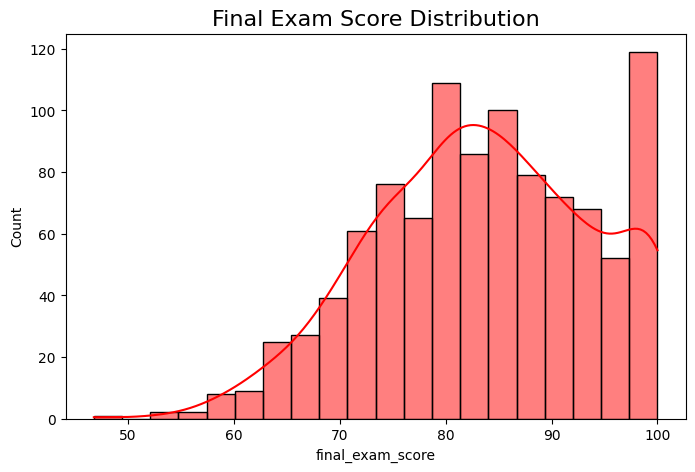

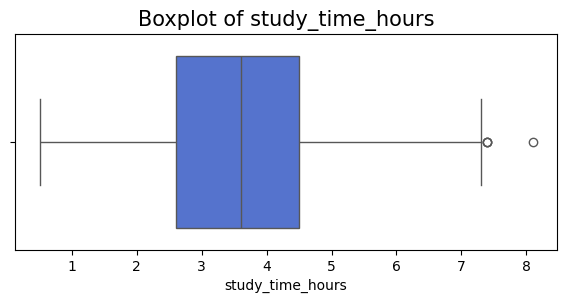

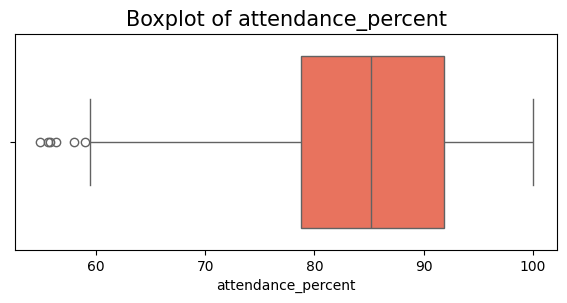

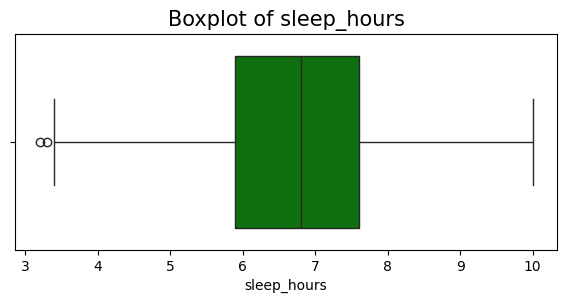

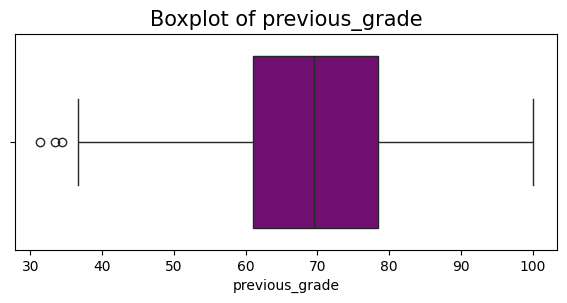

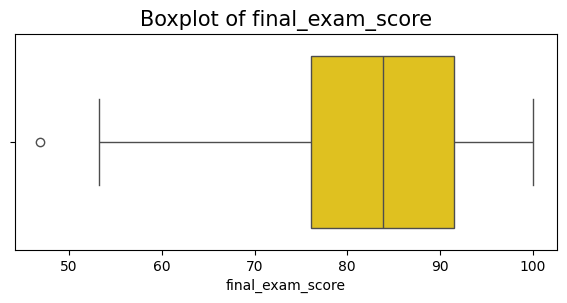

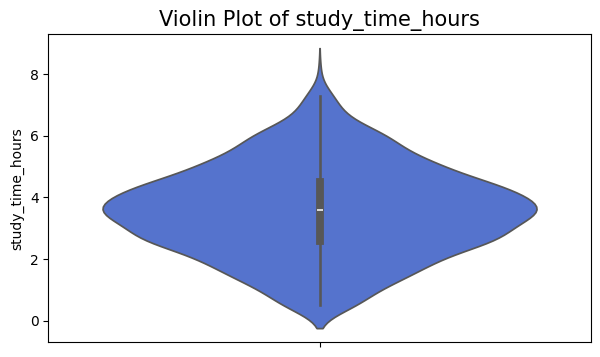

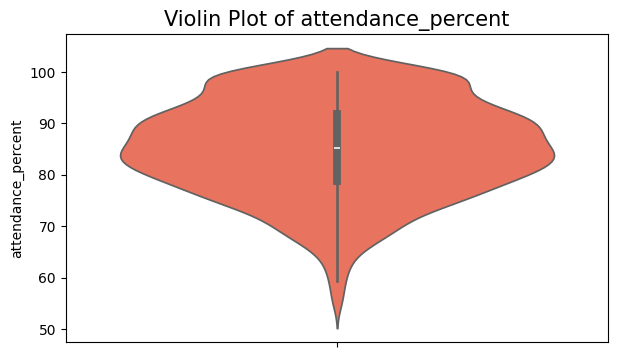

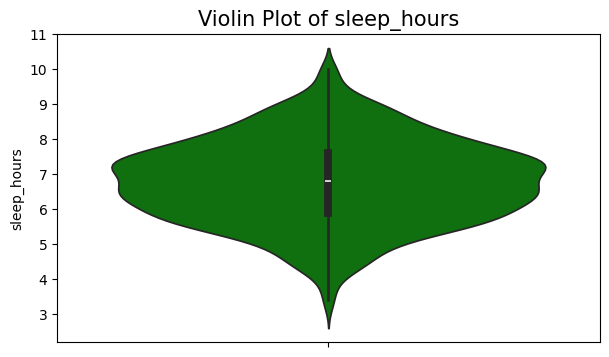

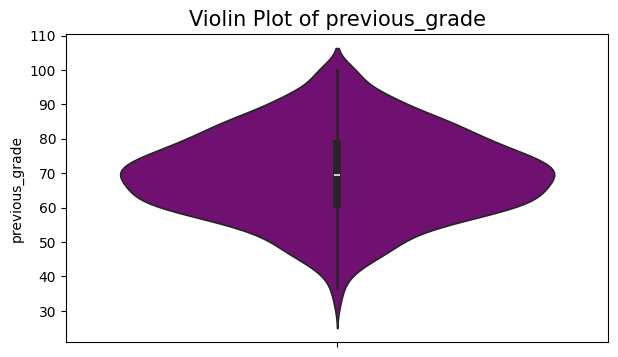

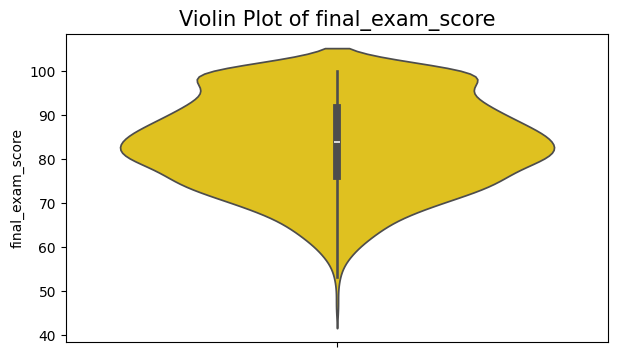

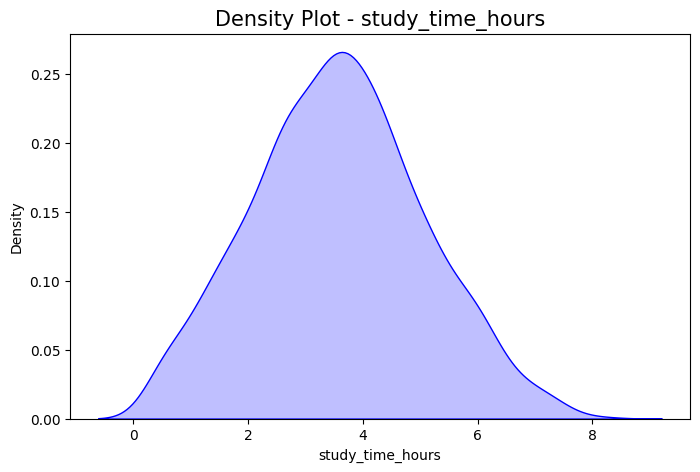

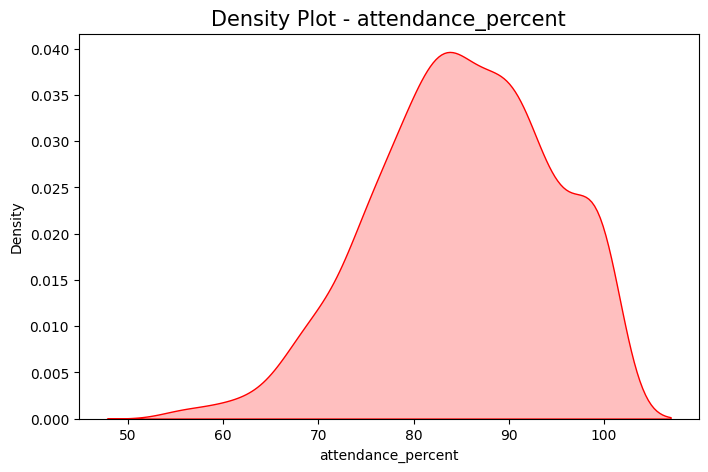

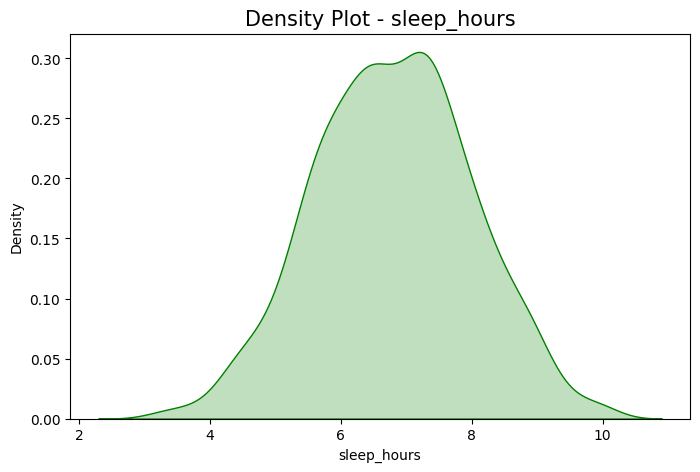

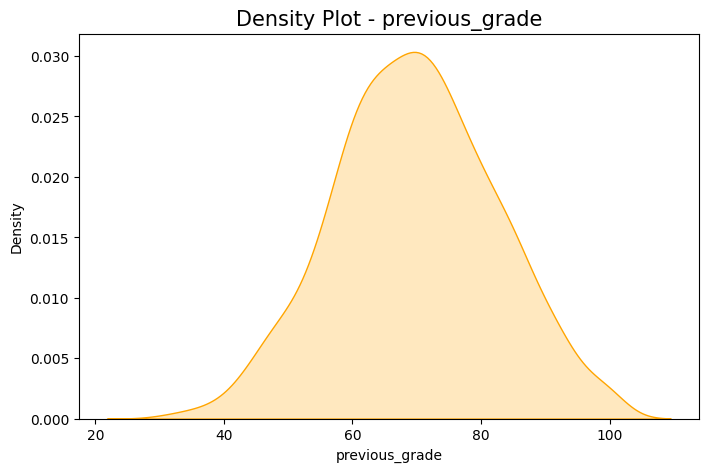

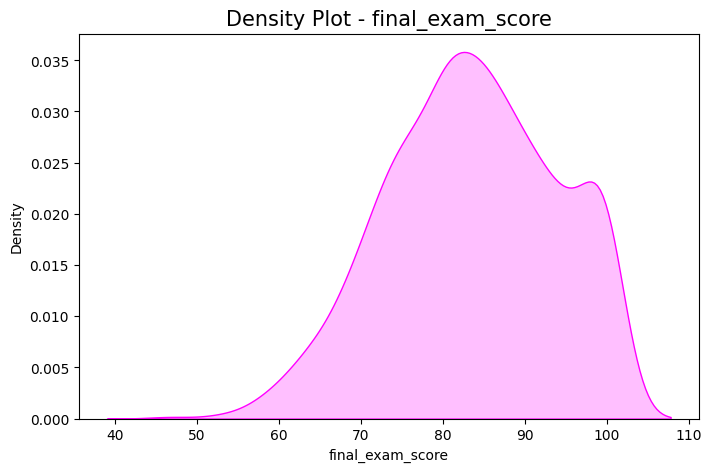

In [12]:
# ============================================================
# STUDENT PERFORMANCE DATASET - VISUALIZATION PART 1
# Dataset Overview + Univariate Analysis
# ============================================================

# ===========================
# Import Libraries


# ==========================================
# Basic Information
# ==========================================

print("="*60)
print("First Five Rows")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Information")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)
print(df.describe(include='all'))

# ============================================================
# Numerical and Categorical Columns
# ============================================================

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

# ============================================================
# Missing Values Heatmap
# ============================================================

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values Heatmap",fontsize=16)
plt.show()

# ============================================================
# Gender Distribution
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='gender',
    data=df,
    hue='gender',
    palette='Set2',
    legend=False
)

plt.title("Gender Distribution",fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

# ============================================================
# Internet Access Distribution
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='internet_access',
    data=df,
    hue='internet_access',
    palette='coolwarm',
    legend=False
)

plt.title("Internet Access",fontsize=16)

plt.show()

# ============================================================
# Extracurricular Activities
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='extracurricular_activities',
    data=df,
    hue='extracurricular_activities',
    palette='Accent',
    legend=False
)

plt.title("Extracurricular Activities",fontsize=16)

plt.show()

# ============================================================
# Part Time Job
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='part_time_job',
    data=df,
    hue='part_time_job',
    palette='Dark2',
    legend=False
)

plt.title("Part Time Job Distribution",fontsize=16)

plt.show()

# ============================================================
# Final Grade Distribution
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='final_grade',
    data=df,
    hue='final_grade',
    palette='Set3',
    legend=False
)

plt.title("Final Grade Distribution",fontsize=16)

plt.show()

# ============================================================
# Histogram - Study Time
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['study_time_hours'],
    bins=20,
    kde=True,
    color='royalblue'
)

plt.title("Study Time Distribution",fontsize=16)

plt.xlabel("Study Time (Hours)")

plt.show()

# ============================================================
# Histogram - Attendance
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['attendance_percent'],
    bins=20,
    kde=True,
    color='orange'
)

plt.title("Attendance Percentage",fontsize=16)

plt.xlabel("Attendance %")

plt.show()

# ============================================================
# Histogram - Sleep Hours
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['sleep_hours'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Sleep Hours Distribution",fontsize=16)

plt.xlabel("Sleep Hours")

plt.show()

# ============================================================
# Histogram - Previous Grade
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['previous_grade'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title("Previous Grade Distribution",fontsize=16)

plt.show()

# ============================================================
# Histogram - Final Exam Score
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['final_exam_score'],
    bins=20,
    kde=True,
    color='red'
)

plt.title("Final Exam Score Distribution",fontsize=16)

plt.show()

# ============================================================
# Boxplots
# ============================================================

box_colors = [
    'royalblue',
    'tomato',
    'green',
    'purple',
    'gold'
]

box_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score'
]

for col, clr in zip(box_columns, box_colors):

    plt.figure(figsize=(7,2.8))

    sns.boxplot(
        x=df[col],
        color=clr
    )

    plt.title(f'Boxplot of {col}',fontsize=15)

    plt.show()

# ============================================================
# Violin Plots
# ============================================================

for col, clr in zip(box_columns, box_colors):

    plt.figure(figsize=(7,4))

    sns.violinplot(
        y=df[col],
        color=clr
    )

    plt.title(f'Violin Plot of {col}',fontsize=15)

    plt.show()

# ============================================================
# Density Plots
# ============================================================

density_colors = [
    'blue',
    'red',
    'green',
    'orange',
    'magenta'
]

for col, clr in zip(box_columns, density_colors):

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        color=clr
    )

    plt.title(f'Density Plot - {col}',fontsize=15)

    plt.show()


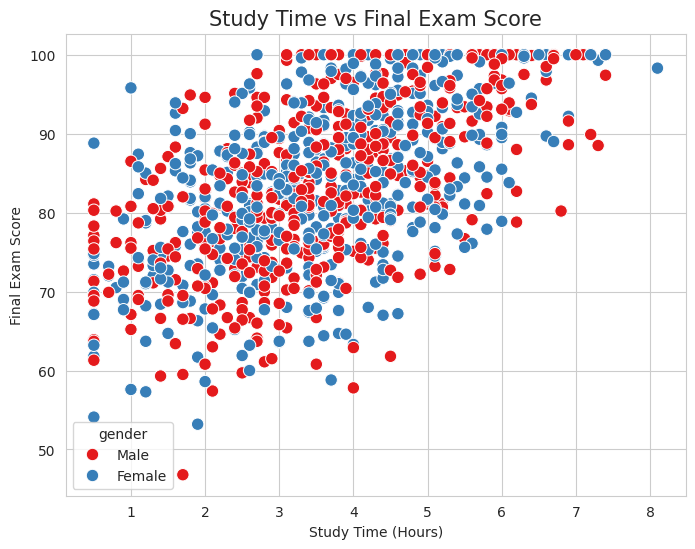

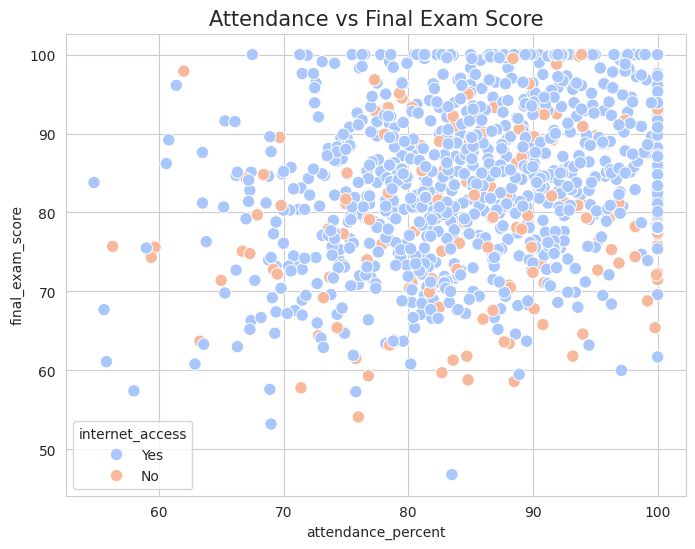

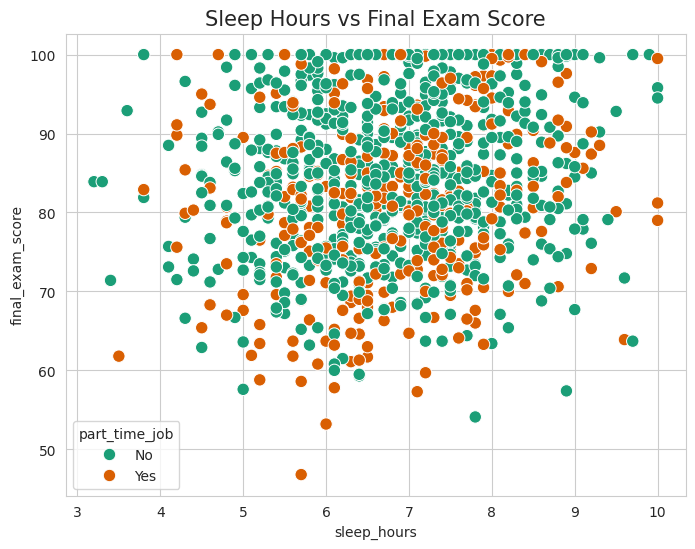

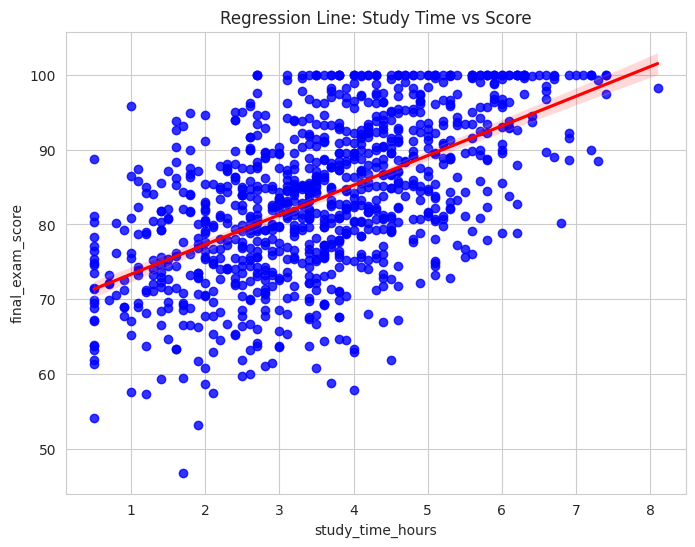

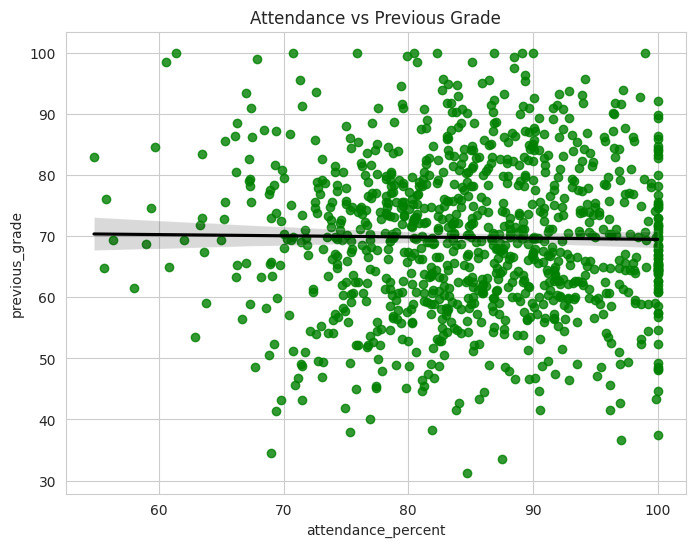

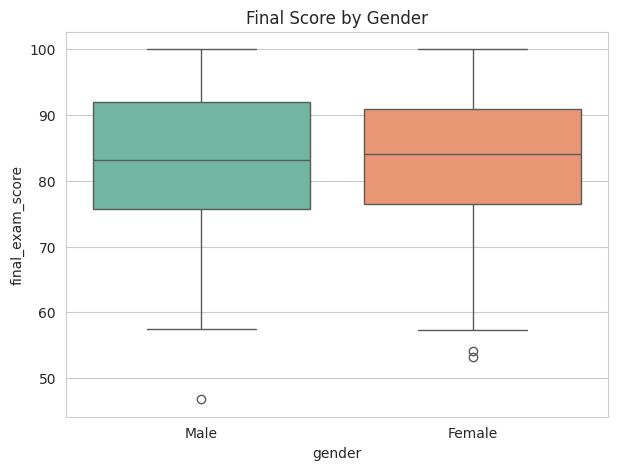

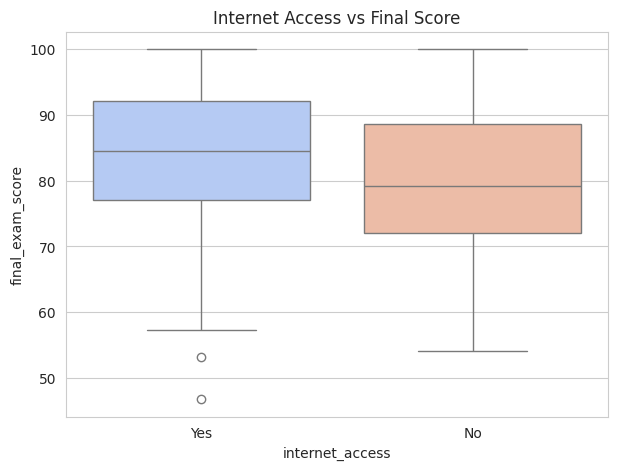

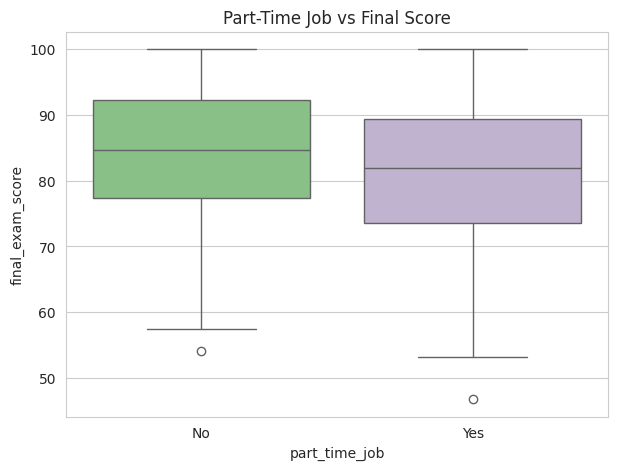

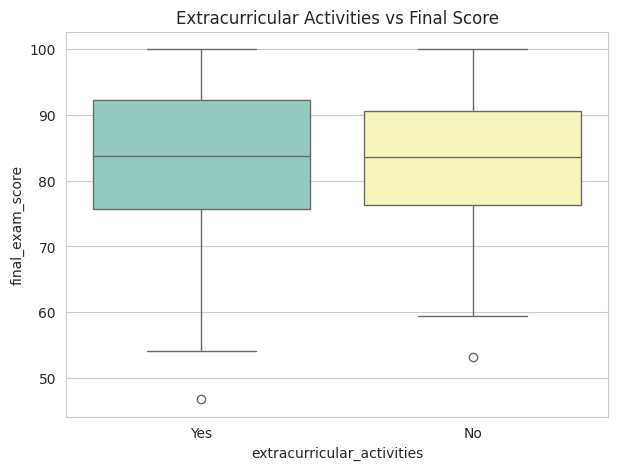

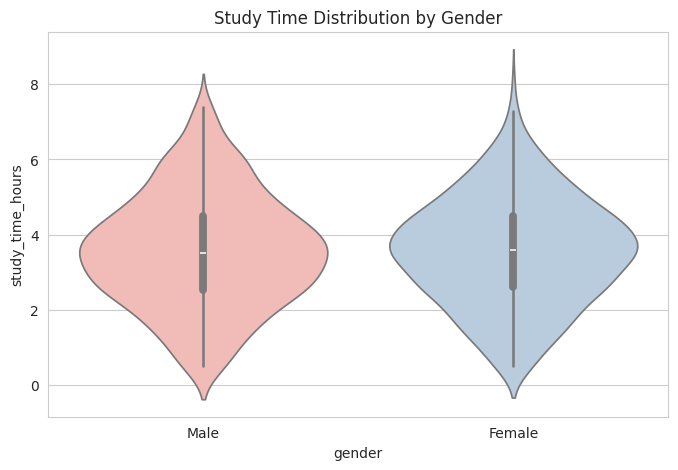

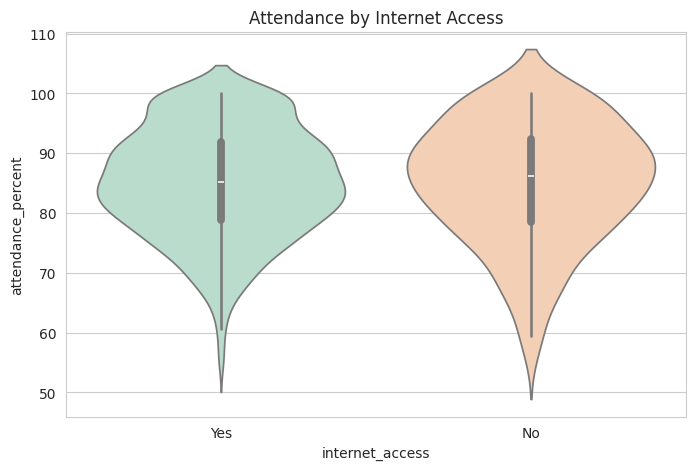

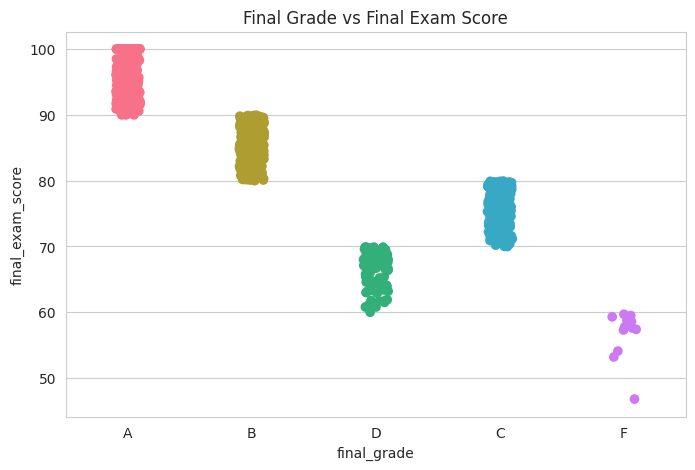

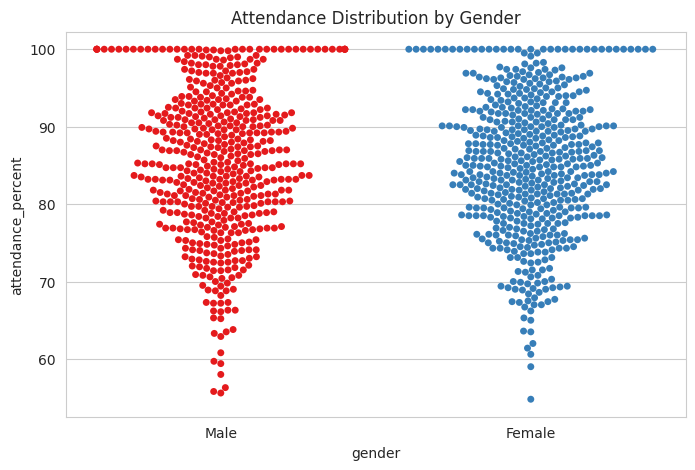

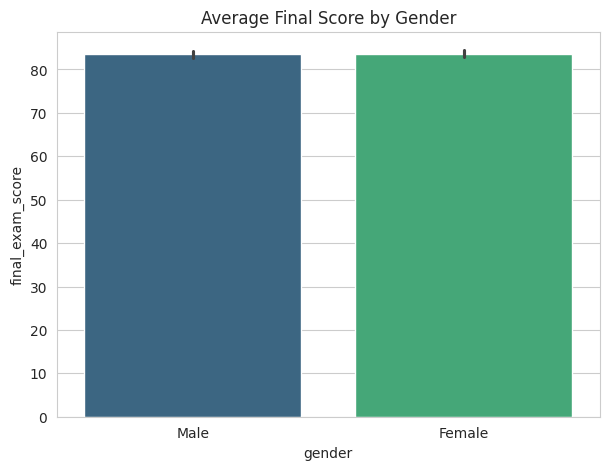

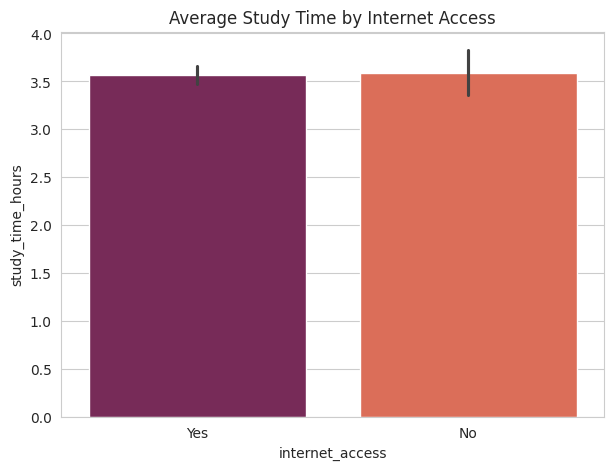

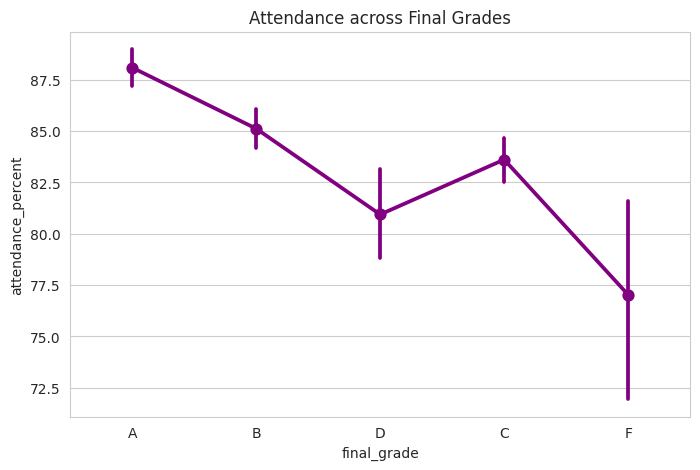

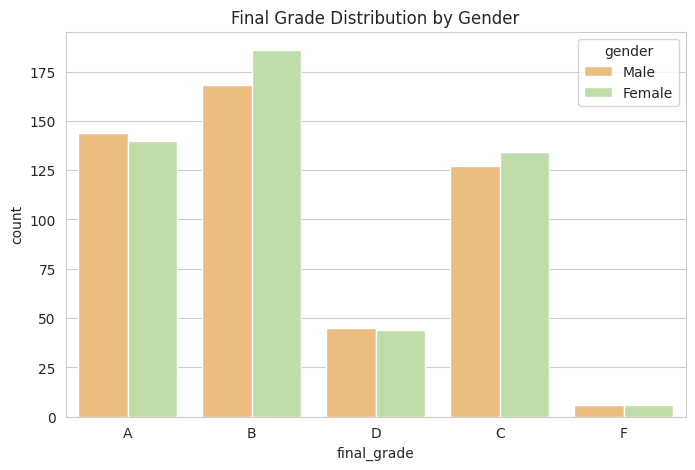

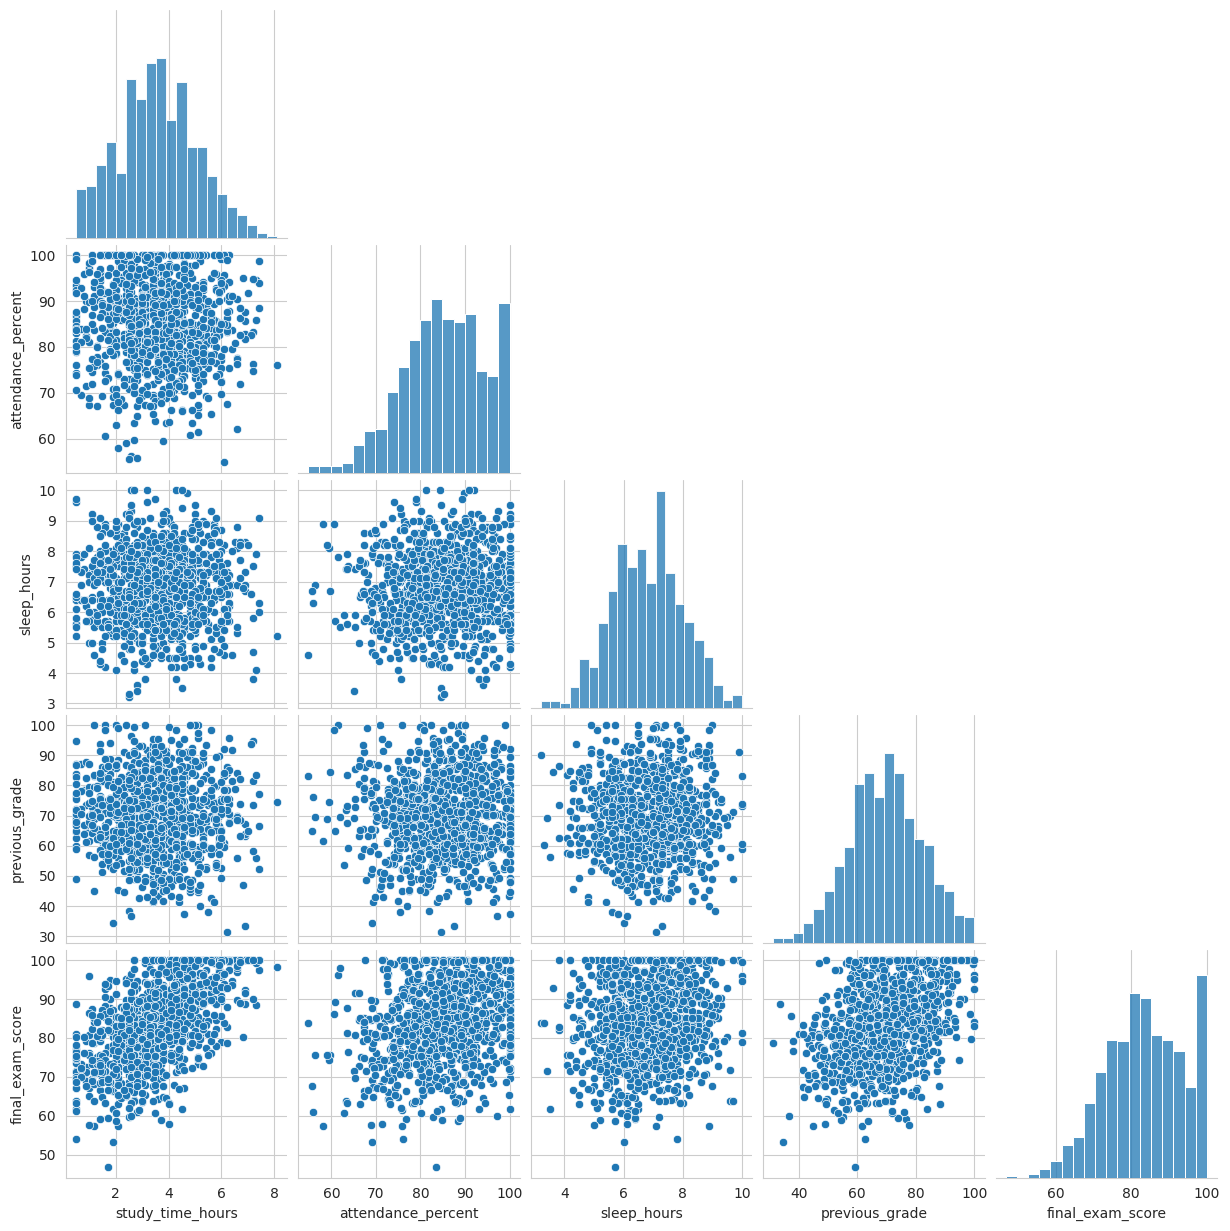

In [13]:
# ============================================================
# STUDENT PERFORMANCE DATASET - VISUALIZATION PART 2
# BIVARIATE ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ============================================================
# Scatter Plot
# Study Time vs Final Exam Score
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='study_time_hours',
    y='final_exam_score',
    hue='gender',
    palette='Set1',
    s=80
)

plt.title("Study Time vs Final Exam Score", fontsize=15)
plt.xlabel("Study Time (Hours)")
plt.ylabel("Final Exam Score")
plt.grid(True)
plt.show()

# ============================================================
# Attendance vs Final Exam Score
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='attendance_percent',
    y='final_exam_score',
    hue='internet_access',
    palette='coolwarm',
    s=80
)

plt.title("Attendance vs Final Exam Score", fontsize=15)
plt.grid(True)

plt.show()

# ============================================================
# Sleep Hours vs Final Exam Score
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='final_exam_score',
    hue='part_time_job',
    palette='Dark2',
    s=80
)

plt.title("Sleep Hours vs Final Exam Score", fontsize=15)

plt.show()

# ============================================================
# Regression Plot
# ============================================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='study_time_hours',
    y='final_exam_score',
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"}
)

plt.title("Regression Line: Study Time vs Score")

plt.show()

# ============================================================
# Attendance vs Previous Grade
# ============================================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='attendance_percent',
    y='previous_grade',
    scatter_kws={"color":"green"},
    line_kws={"color":"black"}
)

plt.title("Attendance vs Previous Grade")

plt.show()

# ============================================================
# Boxplot
# Final Score by Gender
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='gender',
    y='final_exam_score',
    hue='gender',
    palette='Set2',
    legend=False
)

plt.title("Final Score by Gender")

plt.show()

# ============================================================
# Boxplot
# Final Score by Internet Access
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='internet_access',
    y='final_exam_score',
    hue='internet_access',
    palette='coolwarm',
    legend=False
)

plt.title("Internet Access vs Final Score")

plt.show()

# ============================================================
# Boxplot
# Final Score by Part-Time Job
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='part_time_job',
    y='final_exam_score',
    hue='part_time_job',
    palette='Accent',
    legend=False
)

plt.title("Part-Time Job vs Final Score")

plt.show()

# ============================================================
# Boxplot
# Final Score by Extracurricular Activities
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='extracurricular_activities',
    y='final_exam_score',
    hue='extracurricular_activities',
    palette='Set3',
    legend=False
)

plt.title("Extracurricular Activities vs Final Score")

plt.show()

# ============================================================
# Violin Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='gender',
    y='study_time_hours',
    palette='Pastel1',
    hue='gender',
    legend=False
)

plt.title("Study Time Distribution by Gender")

plt.show()

# ============================================================
# Violin Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='internet_access',
    y='attendance_percent',
    palette='Pastel2',
    hue='internet_access',
    legend=False
)

plt.title("Attendance by Internet Access")

plt.show()

# ============================================================
# Strip Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.stripplot(
    data=df,
    x='final_grade',
    y='final_exam_score',
    palette='husl',
    hue='final_grade',
    size=7,
    legend=False
)

plt.title("Final Grade vs Final Exam Score")

plt.show()

# ============================================================
# Swarm Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.swarmplot(
    data=df,
    x='gender',
    y='attendance_percent',
    hue='gender',
    palette='Set1',
    size=5,
    legend=False
)

plt.title("Attendance Distribution by Gender")

plt.show()

# ============================================================
# Bar Plot
# Average Final Exam Score by Gender
# ============================================================

plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='gender',
    y='final_exam_score',
    hue='gender',
    palette='viridis',
    legend=False
)

plt.title("Average Final Score by Gender")

plt.show()

# ============================================================
# Bar Plot
# ============================================================

plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='internet_access',
    y='study_time_hours',
    hue='internet_access',
    palette='rocket',
    legend=False
)

plt.title("Average Study Time by Internet Access")

plt.show()

# ============================================================
# Point Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df,
    x='final_grade',
    y='attendance_percent',
    color='purple'
)

plt.title("Attendance across Final Grades")

plt.show()

# ============================================================
# Count Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='final_grade',
    hue='gender',
    palette='Spectral'
)

plt.title("Final Grade Distribution by Gender")

plt.show()

# ============================================================
# Pairplot
# ============================================================

sns.pairplot(
    df[
        [
            'study_time_hours',
            'attendance_percent',
            'sleep_hours',
            'previous_grade',
            'final_exam_score'
        ]
    ],
    corner=True,
    diag_kind='hist'
)

plt.show()



## Features Engineering

In [14]:
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

In [15]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


In [16]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=2, gamma='scale'))
])

In [19]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'final_exam_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'internet_access', 'extracurricular_activities',
       'part_time_job'],
      dtype='object'))])),
                ('classifier', SVC(C=2))])

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy:.2%}\n")

Accuracy Score : 90.50%



              precision    recall  f1-score   support

           A       0.96      0.95      0.96        57
           B       0.87      0.92      0.89        71
           C       0.90      0.87      0.88        52
           D       0.89      0.94      0.92        18
           F       0.00      0.00      0.00         2

    accuracy                           0.91       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.90      0.91      0.90       200



<Figure size 800x600 with 0 Axes>

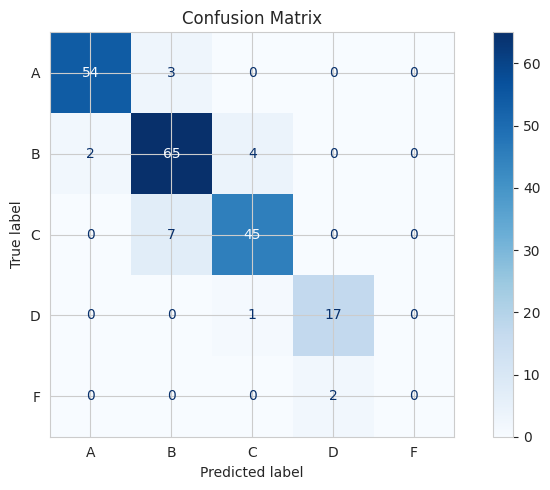

In [22]:
print(classification_report(y_test, y_pred))

fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## Thanks................Please Upvote